<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/Price_RNN_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
import matplotlib.pyplot as plt

In [ ]:
#function to plot data
def plot_series(data, title="Time Series Data", xlabel="Date", ylabel="Value", figsize=(16, 4)):
  plt.figure(figsize=figsize)
  plt.plot(data)
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.show()

In [ ]:
nse_ticker="RELIANCE.NS"
start_date="2023-08-25"
end_date="2024-08-25"

nse_data=yf.download(nse_ticker, start=start_date, end=end_date)
df=nse_data.reset_index()
df.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2023-08-25,1225.825806,1244.026788,1213.037906,1219.692531,22222400
1,2023-08-28,1213.609009,1233.597863,1207.326846,1227.638453,12580826
2,2023-08-29,1201.988159,1218.426125,1195.929329,1217.730909,16876644
3,2023-08-30,1200.845947,1213.236529,1199.331240,1207.773737,12168946
4,2023-08-31,1195.358276,1204.297391,1191.832244,1203.304156,21638600


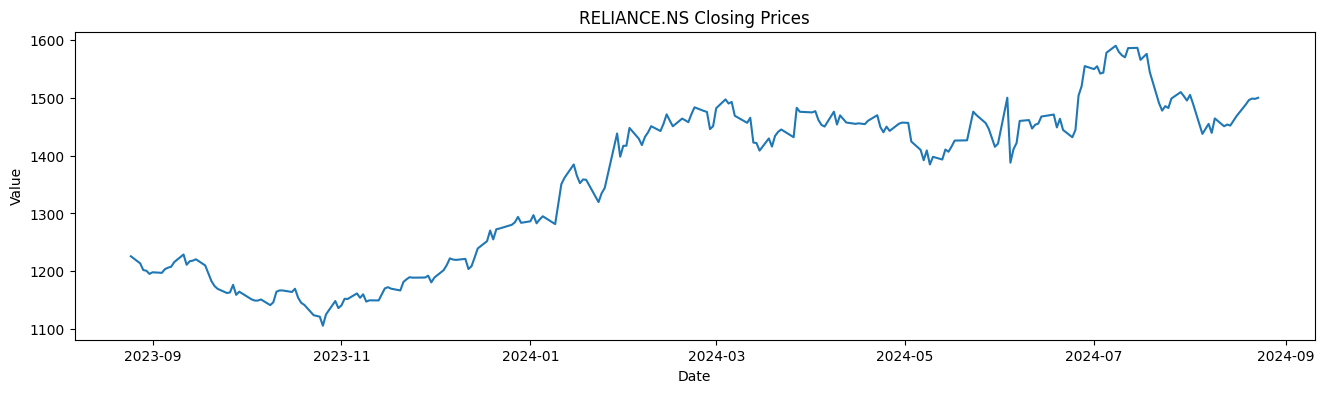

In [ ]:
#select the 'close' price and reset index
rel_close=df[['Date','Close']]
rel_close.set_index('Date', inplace=True)

#plot the close prices
plot_series(rel_close, title="RELIANCE.NS Closing Prices")

In [ ]:
# Train-Test Split (85% training, 15% testing)

train_size=int(len(rel_close)* 0.85)
train=rel_close.iloc[:train_size]
test=rel_close.iloc[train_size:]

In [ ]:
# Scale the data

scaler=MinMaxScaler()
scaled_train=scaler.fit_transform(train)
scaled_test=scaler.transform(test)

In [ ]:
# Function to create and compile RNN model

def build_rnn_model(input_shape):
  model=Sequential()
  model.add(SimpleRNN(50, input_shape=input_shape))
  model.add(Dropout(rate=0.5))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mse')
  return model

In [ ]:
# Function to create and compile LSTM model

def build_lstm_model(input_shape):
  model=Sequential()
  model.add(LSTM(50, input_shape=input_shape))
  model.add(Dropout(rate=0.5))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mse')
  return model

In [ ]:
# Create TimeseriesGenerator

length=16
batch_size=32
n_features=1

train_generator=TimeseriesGenerator(scaled_train, scaled_train, length=length, batch_size=batch_size)

In [ ]:
# Build and train the RNN model

rnn_model=build_rnn_model(input_shape=(length, n_features))
rnn_model.summary()

rnn_model.fit(train_generator, epochs=10, shuffle=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1205
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0384 
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0401 
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0329 
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0244  
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0182  
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0195
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0143
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0165 
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0185 


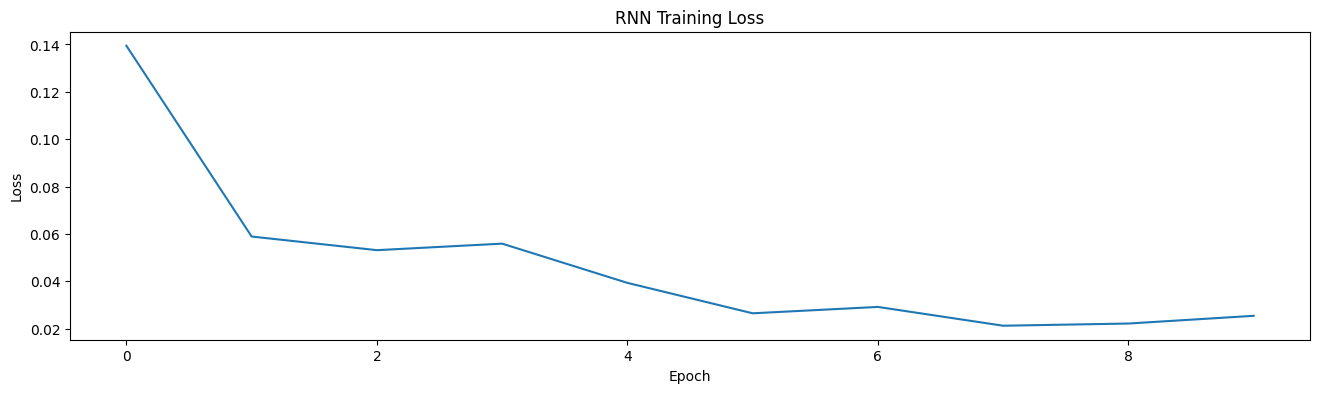

In [ ]:
# plot the training loss for RNN

losses_rnn=pd.DataFrame(rnn_model.history.history)
plot_series(losses_rnn, title="RNN Training Loss", xlabel="Epoch", ylabel="Loss")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


<ipython-input-13-e94825b90960>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['RNN_Predictions']=np.nan
<ipython-input-13-e94825b90960>:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single 

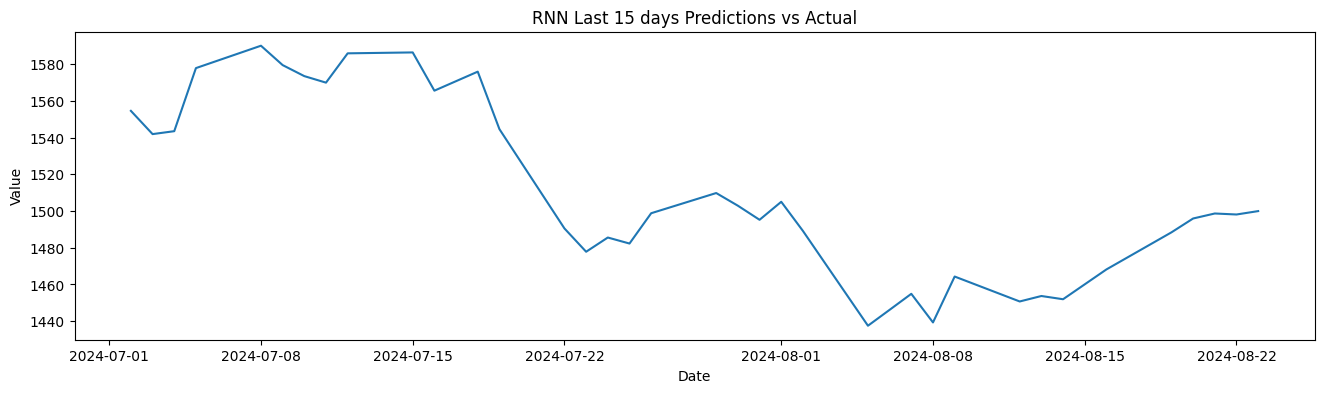

In [ ]:
# Forecast the last 15 days of the test set using RNN
initial_batch_rnn=scaled_train[-length:].reshape((1, length, n_features))
rnn_predictions=[]

for i in range(15):
  current_pred=rnn_model.predict(initial_batch_rnn)[0]
  rnn_predictions.append(current_pred)
  initial_batch_rnn=np.append(initial_batch_rnn[:, 1:, :],[[current_pred]], axis=1)

# Inverse scale the RNN predictions to get actual values
rnn_predictions=scaler.inverse_transform(rnn_predictions)

# Add RNN predictions to the test dataframe
test['RNN_Predictions']=np.nan
test['RNN_Predictions'].iloc[-15:]=rnn_predictions.flatten()

# Plot actual vs RNN Predicted values
plot_series(test[['Close', 'RNN_Predictions']], title='RNN Last 15 days Predictions vs Actual')

In [ ]:
#print(test['Close'].isna().sum())
#print(test['RNN_Predictions'].isna().sum())

In [ ]:
#test=test.dropna()

In [ ]:
#test['Close'].fillna(test['Close'].mean(), inplace=True)
#test['RNN_Predictions'].fillna(test['RNN_Predictions'].mean(), inplace=True)

In [ ]:
#print(len(test['Close']), len(test['RNN_Predictions']))

In [ ]:
# Calculate the error metrics for RNN
rmse_rnn=np.sqrt(mean_squared_error(test['Close'].iloc[-15:], test['RNN_Predictions'].iloc[-15:]))
mae_rnn=mean_absolute_error(test['Close'].iloc[-15:], test['RNN_Predictions'].iloc[-15:])

print(f'RNN RMSE: {rmse_rnn}')
print(f'RNN MAE: {mae_rnn}')

ValueError: Input contains NaN.

In [ ]:
print(test.iloc[-15:])

Price             Close RNN_Predictions
Ticker      RELIANCE.NS                
Date                                   
2024-08-02  1489.182007             NaN
2024-08-05  1437.533813             NaN
2024-08-06  1446.199829             NaN
2024-08-07  1454.915405             NaN
2024-08-08  1439.321655             NaN
2024-08-09  1464.326416             NaN
2024-08-12  1450.743896             NaN
2024-08-13  1453.723511             NaN
2024-08-14  1451.960571             NaN
2024-08-16  1468.199951             NaN
2024-08-19  1488.400024             NaN
2024-08-20  1495.949951             NaN
2024-08-21  1498.675049             NaN
2024-08-22  1498.125000             NaN
2024-08-23  1499.974976             NaN


In [ ]:
print(test[['Close', 'RNN_Predictions']].isnull().sum())  # بررسی وجود NaN

Price            Ticker     
Close            RELIANCE.NS     0
RNN_Predictions                 37
dtype: int64


In [ ]:
test['Close'].fillna(test['Close'].mean(), inplace=True)
test['RNN_Predictions'].fillna(test['RNN_Predictions'].mean(), inplace=True)


<ipython-input-21-424f3d8f5132>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Close'].fillna(test['Close'].mean(), inplace=True)
<ipython-input-21-424f3d8f5132>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['RNN_Predictions'].fillna(test['RNN_Predictions'].mean(), inplace=True)


In [ ]:
print(len(test['Close']), len(test['RNN_Predictions']))


37 37


In [ ]:
# Calculate the error metrics for RNN
rmse_rnn=np.sqrt(mean_squared_error(test['Close'].iloc[-15:], test['RNN_Predictions'].iloc[-15:]))
mae_rnn=mean_absolute_error(test['Close'].iloc[-15:], test['RNN_Predictions'].iloc[-15:])

print(f'RNN RMSE: {rmse_rnn}')
print(f'RNN MAE: {mae_rnn}')

ValueError: Input contains NaN.

In [ ]:
# Build and train the LSTM model

lstm_model=build_lstm_model(input_shape=(length, n_features))
lstm_model.summary()

lstm_model.fit(train_generator, epochs=10, shuffle=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0941
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0316
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0248
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0254
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0171
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0185
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0120
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0133
Epoch 9/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0172
Epoch 10/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0127


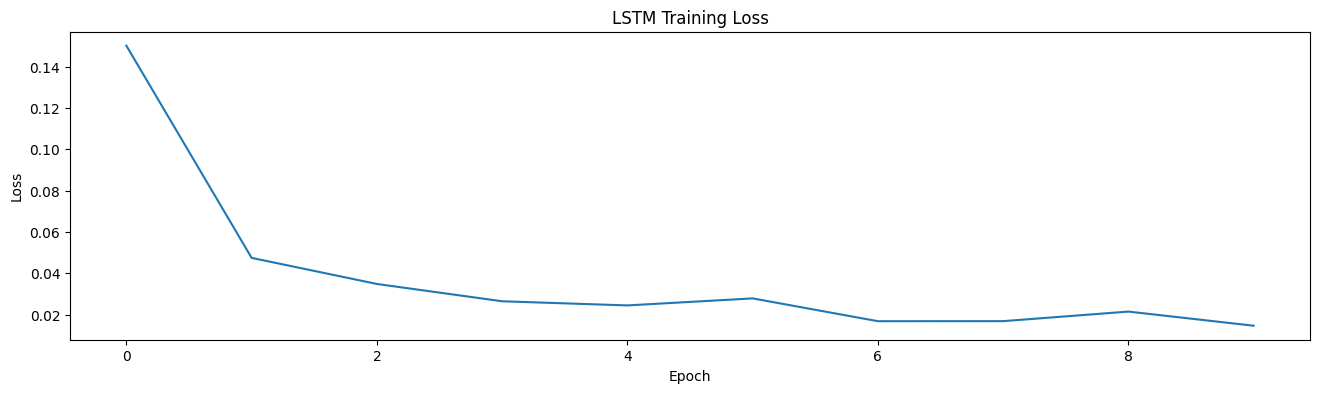

In [ ]:
# Plot the training loss for LSTM

losses_lstm=pd.DataFrame(lstm_model.history.history)
plot_series(losses_lstm, title='LSTM Training Loss', xlabel='Epoch', ylabel='Loss')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


<ipython-input-26-bcf58afcd9b4>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['LSTM_Predictions']=np.nan
<ipython-input-26-bcf58afcd9b4>:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single

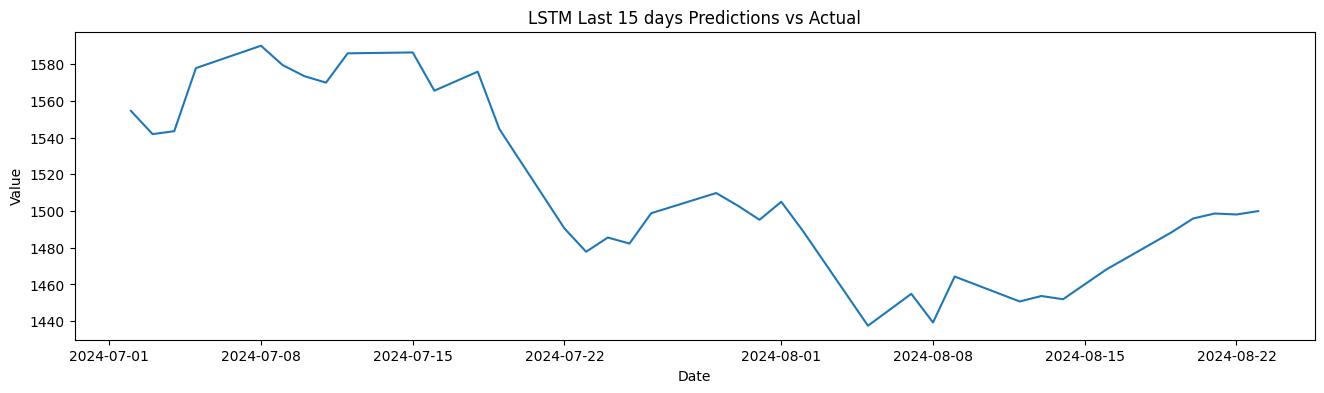

In [ ]:
# Forecast the last 15 days of the test set using LSTM
initial_batch_lstm=scaled_train[-length:].reshape((1, length, n_features))
lstm_predictions=[]

for i in range(15):
  current_pred=lstm_model.predict(initial_batch_lstm)[0]
  lstm_predictions.append(current_pred)
  initial_batch_lstm=np.append(initial_batch_lstm[:, 1:, :],[[current_pred]], axis=1)

# Inverse scale the LSTM predictions to get actual values
lstm_predictions=scaler.inverse_transform(lstm_predictions)

# Add LSTM predictions to the test dataframe
test['LSTM_Predictions']=np.nan
test['LSTM_Predictions'].iloc[-15:]=lstm_predictions.flatten()

# Plot actual vs LSTM Predicted values
plot_series(test[['Close', 'LSTM_Predictions']], title='LSTM Last 15 days Predictions vs Actual')

In [ ]:
# Calculate the error metrics for LSTM
rmse_lstm=np.sqrt(mean_squared_error(test['Close'].iloc[-15:], test['LSTM_Predictions'].iloc[-15:]))
mae_lstm=mean_absolute_error(test['Close'].iloc[-15:], test['LSTM_Predictions'].iloc[-15:])

print(f'LSTM RMSE: {rmse_lstm}')
print(f'LSTM MAE: {mae_lstm}')

ValueError: Input contains NaN.

In [ ]:
# Scale the full dataset
full_scaler=MinMaxScaler()
scaled_full_data=full_scaler.fit_transform(rel_close)

#Create TimeseriesGenerator for the full dataset
full_generator=TimeseriesGenerator(scaled_full_data, scaled_full_data, length=length, batch_size=batch_size)

#Build and train the RNN model on the full dataset
rnn_full_model=build_rnn_model(input_shape=(length, n_features))
rnn_full_model.summary()

rnn_full_model.fit(full_generator, epochs=10, shuffle=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.3636
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1450
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0862
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0651
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0273
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0276
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0299
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0243
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0216
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0283


In [ ]:
# Forecast the next 15 days using the trained RNN model
rnn_forecast=[]
current_batch_rnn=scaled_full_data[-length:].reshape((1, length, n_features))

for i in range(15):
  current_pred=rnn_full_model.predict(current_batch_rnn)[0]
  rnn_forecast.append(current_pred)
  current_batch_rnn=np.append(current_batch_rnn[:, 1:, :], [[current_pred]], axis=1)

# Inverse scale the RNN forecasst to get actual values
rnn_forecast=full_scaler.inverse_transform(rnn_forecast)

# Add RNN forecast to the orginal dataframe
rnn_forecast_dates=pd.date_range(start=rel_close.index[-1] + pd.Timedelta(days=1), periods=15)
rnn_forecast_df=pd.DataFrame(rnn_forecast, index=rnn_forecast_dates, columns=['RNN_Forecast'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


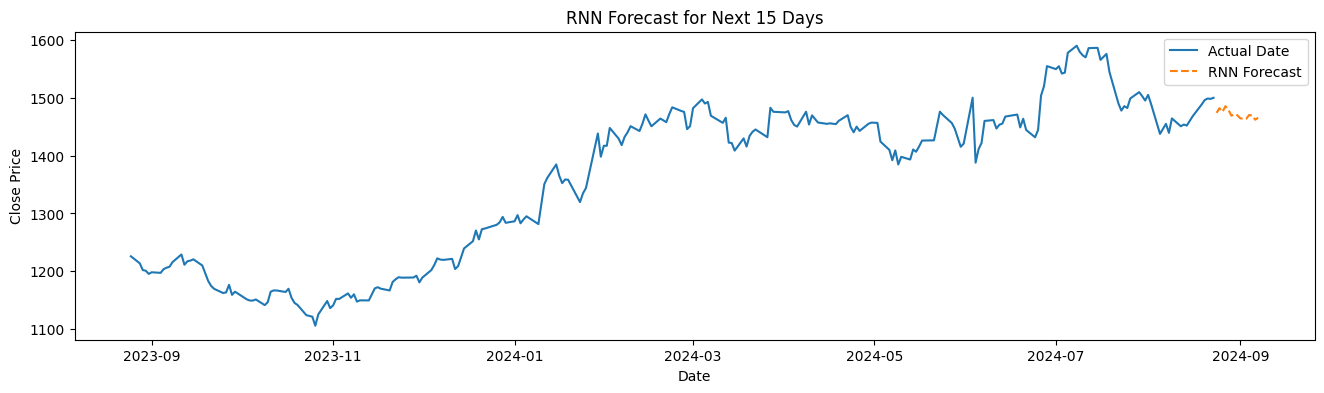

In [ ]:
# Plot the RNN forecast along with the original data
plt.figure(figsize=(16,4))
plt.plot(rel_close, label='Actual Date')
plt.plot(rnn_forecast_df, label='RNN Forecast', linestyle='--')
plt.title('RNN Forecast for Next 15 Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [ ]:
#Build and train the LSTM model on the full dataset
lstm_full_model=build_lstm_model(input_shape=(length, n_features))
lstm_full_model.summary()

lstm_full_model.fit(full_generator, epochs=10, shuffle=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1363
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0238
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0488
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0299
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0176
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0137
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0192
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0166
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0159
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0132


In [ ]:
# Forecast the next 15 days using the trained LSTM model
lstm_forecast=[]
current_batch_lstm=scaled_full_data[-length:].reshape((1, length, n_features))

for i in range(15):
  current_pred=lstm_full_model.predict(current_batch_lstm)[0]
  lstm_forecast.append(current_pred)
  current_batch_lstm=np.append(current_batch_lstm[:, 1:, :], [[current_pred]], axis=1)

# Inverse scale the LSTM forecasst to get actual values
lstm_forecast=full_scaler.inverse_transform(lstm_forecast)

# Add LSTM forecast to the orginal dataframe
lstm_forecast_df=pd.DataFrame(lstm_forecast, index=rnn_forecast_dates, columns=['LSTM_Forecast'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


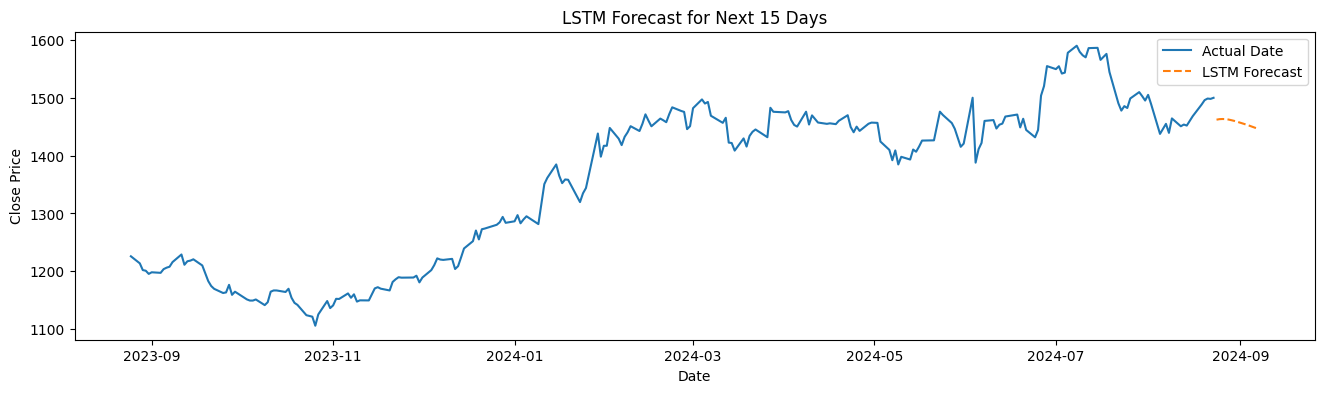

In [ ]:
# Plot the LSTM forecast along with the original data
plt.figure(figsize=(16,4))
plt.plot(rel_close, label='Actual Date')
plt.plot(lstm_forecast_df, label='LSTM Forecast', linestyle='--')
plt.title('LSTM Forecast for Next 15 Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()